## ##  Classification using Deep neural network (Any One from the following) 
1. Multiclass classification using Deep Neural Networks: Example: Use the OCR letter 
recognition dataset https://archive.ics.uci.edu/ml/datasets/letter+recognition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [2]:
# 1. Load dataset directly from URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data"
data = pd.read_csv(url, header=None)

In [3]:
# 2. Split features and labels
X = data.iloc[:, 1:].values   # 16 features
y = data.iloc[:, 0].values    # A-Z labels

In [4]:
# 3. Encode labels (A-Z → 0-25)
le = LabelEncoder()
y = le.fit_transform(y)

In [5]:
# 4. Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# 6. Build DNN model
model = Sequential([
    Input(shape=(16,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(26, activation='softmax')   # 26 classes
])

In [8]:
# 7. Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [9]:
# 8. Train model (store history for graphs)
history = model.fit(
    X_train, 
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5266 - loss: 1.7736 - val_accuracy: 0.7078 - val_loss: 1.0221
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7579 - loss: 0.8386 - val_accuracy: 0.7912 - val_loss: 0.7398
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8164 - loss: 0.6413 - val_accuracy: 0.8228 - val_loss: 0.6086
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8441 - loss: 0.5365 - val_accuracy: 0.8413 - val_loss: 0.5345
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8630 - loss: 0.4659 - val_accuracy: 0.8637 - val_loss: 0.4666
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8814 - loss: 0.4107 - val_accuracy: 0.8759 - val_loss: 0.4224
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8919 - loss: 0.3686 - val_accuracy: 0.8875 - val_loss: 0.3923
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9017 - loss: 0.3334 - val_accuracy: 0.

In [10]:
# 9. Evaluate model
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9523 - loss: 0.1590
Accuracy: 0.9522500038146973


In [11]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


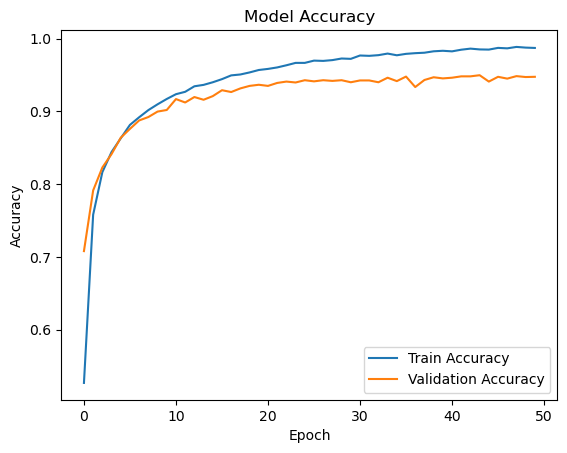

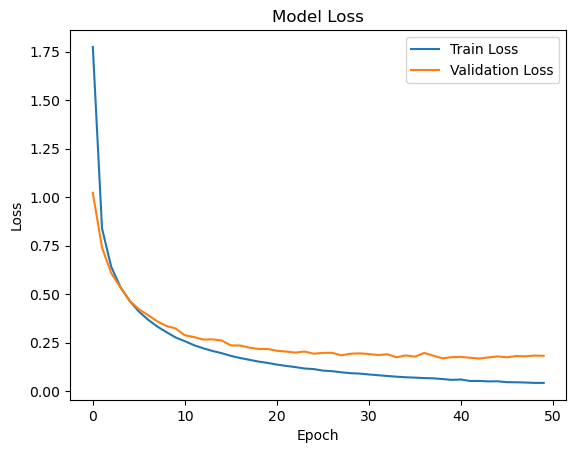

In [12]:
# =========================
# 📊 VISUALIZATION PART
# =========================

# 10. Accuracy Graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 11. Loss Graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


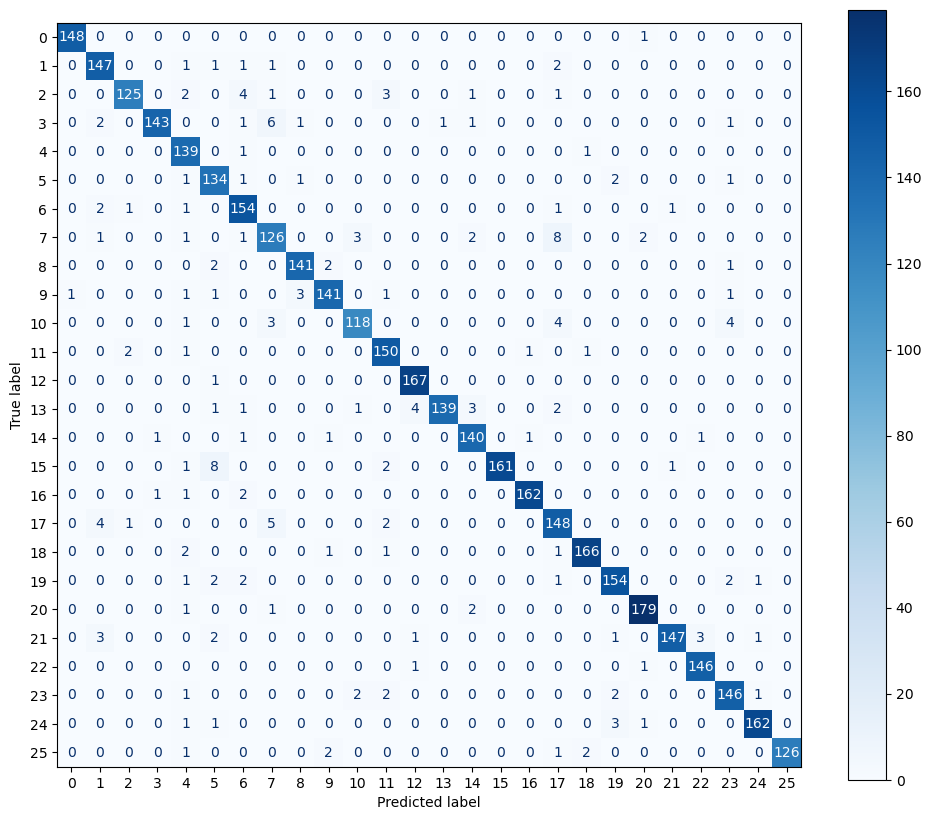

In [13]:
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues', values_format='d')

plt.gcf().set_size_inches(12,10)  # set size AFTER plot
plt.show()

In [14]:
print("\nClassification Report:\n",classification_report(y_test, y_pred_classes))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       149
           1       0.92      0.96      0.94       153
           2       0.97      0.91      0.94       137
           3       0.99      0.92      0.95       156
           4       0.89      0.99      0.93       141
           5       0.88      0.96      0.91       140
           6       0.91      0.96      0.94       160
           7       0.88      0.88      0.88       144
           8       0.97      0.97      0.97       146
           9       0.96      0.95      0.95       149
          10       0.95      0.91      0.93       130
          11       0.93      0.97      0.95       155
          12       0.97      0.99      0.98       168
          13       0.99      0.92      0.96       151
          14       0.94      0.97      0.95       145
          15       1.00      0.93      0.96       173
          16       0.99      0.98      0.98       166
  

In [15]:
# 13. Sample Predictions
print("\nSample Predictions:")
for i in range(len(y_test)):
    print("Actual:", le.inverse_transform([y_test[i]])[0],
          "Predicted:", le.inverse_transform([y_pred_classes[i]])[0])


Sample Predictions:
Actual: T Predicted: X
Actual: L Predicted: L
Actual: A Predicted: A
Actual: E Predicted: E
Actual: Q Predicted: Q
Actual: E Predicted: E
Actual: O Predicted: O
Actual: Q Predicted: Q
Actual: G Predicted: G
Actual: O Predicted: O
Actual: B Predicted: B
Actual: P Predicted: P
Actual: V Predicted: V
Actual: Q Predicted: Q
Actual: M Predicted: M
Actual: V Predicted: V
Actual: B Predicted: B
Actual: K Predicted: K
Actual: S Predicted: S
Actual: D Predicted: D
Actual: B Predicted: B
Actual: P Predicted: P
Actual: Q Predicted: E
Actual: O Predicted: O
Actual: W Predicted: W
Actual: Z Predicted: Z
Actual: N Predicted: N
Actual: Q Predicted: Q
Actual: G Predicted: G
Actual: F Predicted: F
Actual: B Predicted: B
Actual: J Predicted: J
Actual: R Predicted: R
Actual: I Predicted: I
Actual: X Predicted: X
Actual: Y Predicted: Y
Actual: U Predicted: U
Actual: I Predicted: I
Actual: D Predicted: D
Actual: X Predicted: X
Actual: L Predicted: L
Actual: M Predicted: M
Actual: E Pre